# Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Dataset

In [ ]:
studentInfo = pd.read_csv("studentInfo.csv")
studentAssessment = pd.read_csv("studentAssessment.csv")
studentVle = pd.read_csv("studentVle.csv")
assessments = pd.read_csv("assessments.csv")
courses = pd.read_csv("courses.csv")

# Step 3: Calculate Student Engagement




In [ ]:
engagement = studentVle.groupby(['id_student']).sum()['sum_click']

engagement = engagement.reset_index()
engagement.columns = ['id_student','total_clicks']
engagement.head()

,id_student,total_clicks
0,6516,2791
1,8462,656
2,11391,934
3,23629,161
4,23698,910


# Step 4: Calculate Student Performance

In [ ]:
performance = studentAssessment.groupby('id_student')['score'].mean()

performance = performance.reset_index()
performance.columns = ['id_student','avg_score']
display(performance.head())

,id_student,avg_score
0,6516,61.800000
1,8462,87.000000
2,11391,82.000000
3,23629,82.500000
4,23698,74.444444


# Step 5: Merge Data

In [ ]:
data = studentInfo.merge(engagement, on='id_student', how='left')

data = data.merge(performance, on='id_student', how='left')

data.fillna(0, inplace=True)
display(data.head())
print("\nUnique values in 'final_result' after merge and fillna:")
print(data['final_result'].value_counts(dropna=False))

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,total_clicks,avg_score
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0,82.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0,66.4
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0,0.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158.0,76.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034.0,54.4



Unique values in 'final_result' after merge and fillna:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


# 6. Engagement Analysis

This graph shows how actively students interact with the learning system.

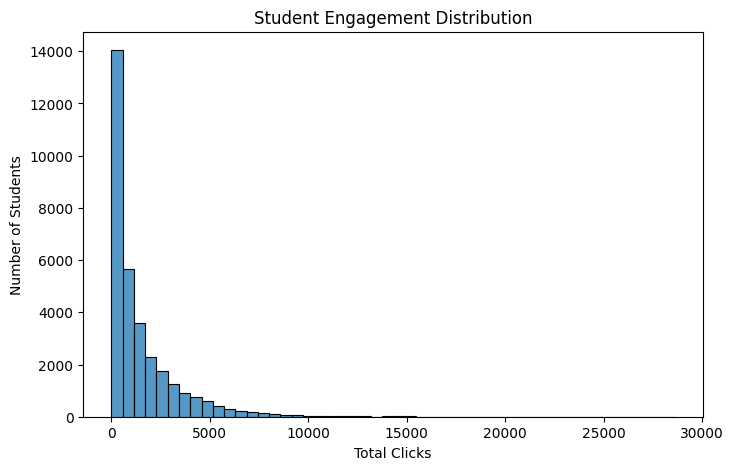

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(data['total_clicks'], bins=50)

plt.title("Student Engagement Distribution")
plt.xlabel("Total Clicks")
plt.ylabel("Number of Students")

plt.show()

# 7. Relationship Between Engagement and Performance

This visualization helps determine whether higher engagement leads to better academic outcomes.

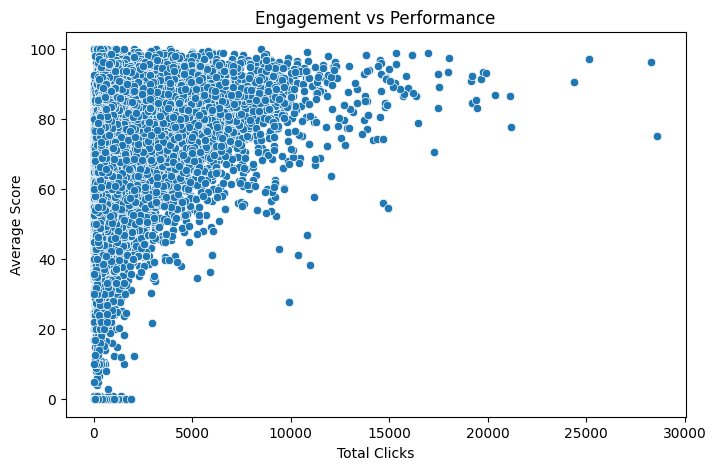

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=data['total_clicks'], y=data['avg_score'])

plt.title("Engagement vs Performance")

plt.xlabel("Total Clicks")
plt.ylabel("Average Score")

plt.show()

# 8. Machine Learning Model

In [ ]:
# Prepare data
print("Unique values in 'final_result' before mapping:")
print(data['final_result'].value_counts(dropna=False))

data['final_result'] = data['final_result'].map({
    'Pass':1,
    'Distinction':1,
    'Fail':0,
    'Withdrawn':0
})

print("\nUnique values in 'final_result' after mapping:")
print(data['final_result'].value_counts(dropna=False))

Unique values in 'final_result' before mapping:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

Unique values in 'final_result' after mapping:
final_result
0    17208
1    15385
Name: count, dtype: int64


In [ ]:
# Feature Selection
features = data[['total_clicks','avg_score']]

target = data['final_result']

9. Train Machine Learning Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Drop rows where target is NaN
cleaned_data = data.dropna(subset=['final_result'])
features = cleaned_data[['total_clicks','avg_score']]
target = cleaned_data['final_result']

X_train, X_test, y_train, y_test = train_test_split(features,target,test_size=0.2)

model = LogisticRegression()

model.fit(X_train,y_train)

pred = model.predict(X_test)

accuracy = accuracy_score(y_test,pred)

print("Model Accuracy:",accuracy)

Model Accuracy: 0.7665286086823132


In [ ]:
print('Descriptive statistics for total_clicks grouped by final_result:')
display(cleaned_data.groupby('final_result')['total_clicks'].describe())

print('\nDescriptive statistics for avg_score grouped by final_result:')
display(cleaned_data.groupby('final_result')['avg_score'].describe())

Descriptive statistics for total_clicks grouped by final_result:


,count,mean,std,min,25%,50%,75%,max
final_result,,,,,,,,
0,17208.0,696.286611,1182.790962,0.0,32.0,269.0,825.25,21204.0
1,15385.0,2354.529477,2356.779266,0.0,779.0,1607.0,3150.00,28615.0



Descriptive statistics for avg_score grouped by final_result:


,count,mean,std,min,25%,50%,75%,max
final_result,,,,,,,,
0,17208.0,43.167650,34.200603,0.0,0.000000,55.000000,72.500000,100.0
1,15385.0,78.235036,11.032256,0.0,71.611111,79.833333,86.555556,100.0


## T-Tests


In [ ]:
from scipy.stats import ttest_ind
print("ttest_ind imported successfully.")

ttest_ind imported successfully.


In [ ]:
pass_students = cleaned_data[cleaned_data['final_result'] == 1]
fail_students = cleaned_data[cleaned_data['final_result'] == 0]

print(f"Number of passing students: {len(pass_students)}")
print(f"Number of failing students: {len(fail_students)}")

Number of passing students: 15385
Number of failing students: 17208


In [ ]:
# The 'final_result' column was already mapped in an earlier step (Cell 08jdkYbUdHLW).
# Re-mapping it here with the same dictionary converts existing numerical values (0/1) to NaN,
# causing cleaned_data to become empty. This block should only re-create cleaned_data
# based on the already mapped 'final_result' in the 'data' DataFrame.

# Re-create cleaned_data ensuring no NaNs in final_result
cleaned_data = data.dropna(subset=['final_result'])

pass_students = cleaned_data[cleaned_data['final_result'] == 1]
fail_students = cleaned_data[cleaned_data['final_result'] == 0]

print(f"Number of passing students: {len(pass_students)}")
print(f"Number of failing students: {len(fail_students)}")

Number of passing students: 15385
Number of failing students: 17208


In [ ]:
t_stat_clicks, p_value_clicks = ttest_ind(pass_students['total_clicks'], fail_students['total_clicks'])
print(f"T-test for Total Clicks:\nT-statistic = {t_stat_clicks:.2f}, P-value = {p_value_clicks:.3e}")

T-test for Total Clicks:
T-statistic = 81.53, P-value = 0.000e+00


In [ ]:
t_stat_score, p_value_score = ttest_ind(pass_students['avg_score'], fail_students['avg_score'])
print(f"\nT-test for Average Score:\nT-statistic = {t_stat_score:.2f}, P-value = {p_value_score:.3e}")


T-test for Average Score:
T-statistic = 121.65, P-value = 0.000e+00


## ANOVA


In [ ]:
from scipy.stats import f_oneway
print("f_oneway imported successfully.")

f_oneway imported successfully.


In [ ]:
print(cleaned_data['highest_education'].value_counts())

highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64


In [ ]:
education_groups = []
for edu_level in cleaned_data['highest_education'].unique():
    group_scores = cleaned_data[cleaned_data['highest_education'] == edu_level]['avg_score']
    education_groups.append(group_scores)

print(f"Number of education groups prepared for ANOVA: {len(education_groups)}")

Number of education groups prepared for ANOVA: 5


In [ ]:
if len(education_groups) < 2:
    print("Cannot perform ANOVA: Not enough education groups with data after filtering.")
    print(f"Number of education groups prepared for ANOVA: {len(education_groups)}")
else:
    f_statistic, p_value = f_oneway(*education_groups)

    print(f"ANOVA for Average Score across Highest Education Levels:")
    print(f"F-statistic = {f_statistic:.2f}, P-value = {p_value:.3e}")

ANOVA for Average Score across Highest Education Levels:
F-statistic = 170.79, P-value = 5.119e-145


## Logistic Regression Analysis



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print("classification_report and confusion_matrix imported successfully.")

classification_report and confusion_matrix imported successfully.



Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.73      0.77      3508
           1       0.72      0.81      0.76      3011

    accuracy                           0.77      6519
   macro avg       0.77      0.77      0.77      6519
weighted avg       0.77      0.77      0.77      6519


Confusion Matrix:


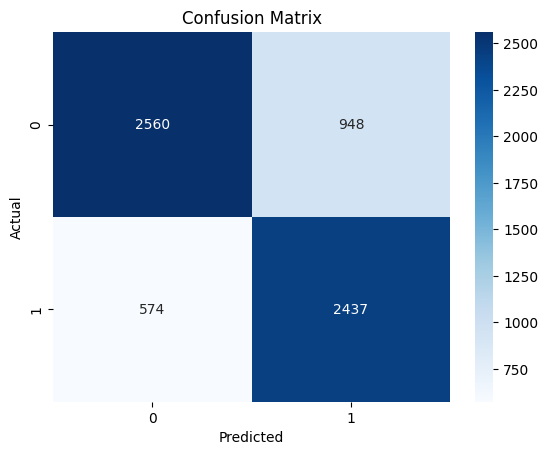

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Ensure features and target are based on the correctly mapped cleaned_data
features = cleaned_data[['total_clicks','avg_score']]
target = cleaned_data['final_result']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = LogisticRegression(random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Model re-trained with binary target. New Accuracy:", accuracy)


Model re-trained with binary target. New Accuracy: 0.7642276422764228


In [ ]:
coefficients = pd.Series(model.coef_[0], index=features.columns)
intercept = model.intercept_[0]

print("Logistic Regression Model Coefficients:")
print(coefficients)
print(f"\nIntercept: {intercept:.4f}")

Logistic Regression Model Coefficients:
total_clicks    0.000429
avg_score       0.060318
dtype: float64

Intercept: -4.7425


## Random Forest Classification


In [ ]:
from sklearn.ensemble import RandomForestClassifier
print("RandomForestClassifier imported successfully.")

RandomForestClassifier imported successfully.


Random Forest Model Accuracy: 0.7690

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.79      0.78      3468
           1       0.75      0.75      0.75      3051

    accuracy                           0.77      6519
   macro avg       0.77      0.77      0.77      6519
weighted avg       0.77      0.77      0.77      6519


Random Forest Confusion Matrix:


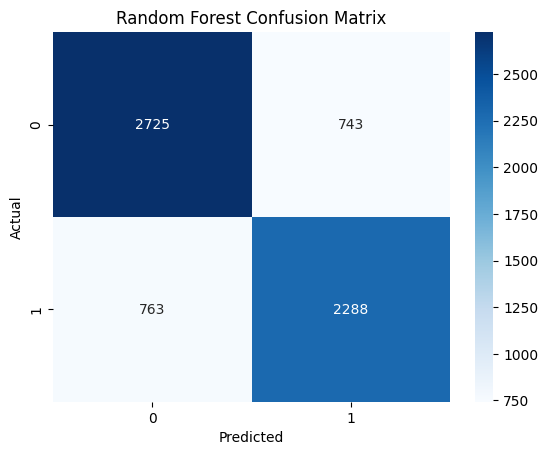


Random Forest Feature Importances:
total_clicks    0.505471
avg_score       0.494529
dtype: float64


In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Model Accuracy: {rf_accuracy:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

print("\nRandom Forest Confusion Matrix:")
rf_cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

feature_importances = pd.Series(rf_model.feature_importances_, index=features.columns)
print("\nRandom Forest Feature Importances:")
print(feature_importances.sort_values(ascending=False))

### Decision Tree Classification


In [ ]:
from sklearn.tree import DecisionTreeClassifier
print("DecisionTreeClassifier imported successfully.")

DecisionTreeClassifier imported successfully.


Decision Tree Model Accuracy: 0.7357

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.78      0.76      3468
           1       0.73      0.68      0.71      3051

    accuracy                           0.74      6519
   macro avg       0.74      0.73      0.73      6519
weighted avg       0.74      0.74      0.73      6519


Decision Tree Confusion Matrix:


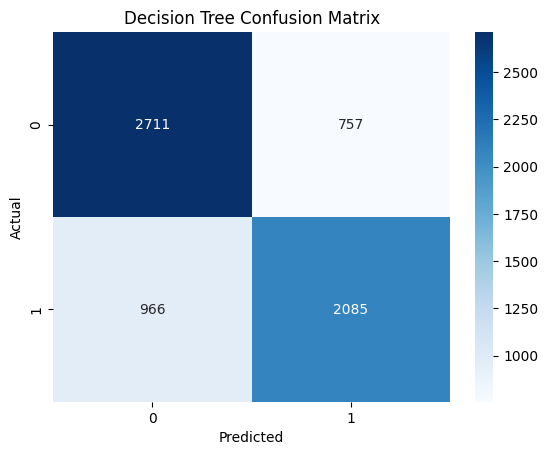

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Model Accuracy: {dt_accuracy:.4f}")

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

print("\nDecision Tree Confusion Matrix:")
dt_cm = confusion_matrix(y_test, dt_pred)
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.tree import plot_tree
print("plot_tree imported successfully.")

plot_tree imported successfully.


## Clustering for Engagement Patterns


In [ ]:
from sklearn.cluster import KMeans
print("KMeans imported successfully.")

KMeans imported successfully.


In [ ]:
from sklearn.preprocessing import StandardScaler

features_for_clustering = cleaned_data[['total_clicks', 'avg_score']]

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)

print("Features for clustering prepared and scaled.")
print("Shape of scaled features:", scaled_features.shape)


Features for clustering prepared and scaled.
Shape of scaled features: (32593, 2)


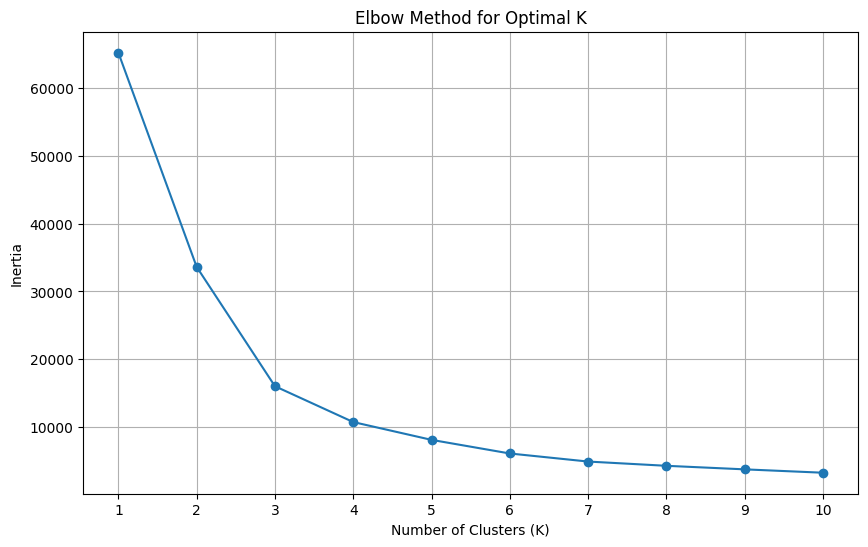

Elbow method plot displayed to determine optimal number of clusters.


In [ ]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()
print("Elbow method plot displayed to determine optimal number of clusters.")

In [ ]:
optimal_k = 4 # Based on the elbow plot, 4 seems to be a reasonable elbow point

kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cleaned_data['cluster'] = kmeans_model.fit_predict(scaled_features)

print(f"K-Means clustering applied with {optimal_k} clusters.")
print("Cluster distribution:")
print(cleaned_data['cluster'].value_counts())


K-Means clustering applied with 4 clusters.
Cluster distribution:
cluster
3    18637
1     6593
0     6335
2     1028
Name: count, dtype: int64


In [ ]:
cluster_centers_df = cleaned_data.groupby('cluster')[['total_clicks', 'avg_score']].mean()
print("Cluster Centers (Mean total_clicks and avg_score per cluster):")
print(cluster_centers_df)

Cluster Centers (Mean total_clicks and avg_score per cluster):
         total_clicks  avg_score
cluster                         
0         3577.508129  79.284903
1           87.624147   2.585018
2         9074.244163  83.123823
3          839.008049  71.991778


In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='total_clicks', y='avg_score', hue='cluster', data=cleaned_data, palette='viridis', s=50, alpha=0.7)
plt.scatter(cluster_centers_df['total_clicks'], cluster_centers_df['avg_score'], marker='X', s=200, color='red', label='Cluster Centers')
plt.title('Student Engagement Patterns (K-Means Clustering)')
plt.xlabel('Total Clicks')
plt.ylabel('Average Score')
plt.legend()
plt.grid(True)
plt.show()


### Final Task


## Summary:

### Data Analysis Key Findings

*   **Correlation between Engagement and Performance**: A moderate positive Pearson correlation of approximately 0.41 was observed between 'total\_clicks' and 'avg\_score', suggesting that higher student engagement (more clicks) is associated with better academic performance.
*   **Significant Differences Between Passing and Failing Students**:
    *   **Total Clicks**: There is a highly statistically significant difference in 'total\_clicks' between students who passed (or achieved distinction) and those who failed (or withdrew), with a T-statistic of 81.53 and a p-value of 0.000e+00.
    *   **Average Score**: Similarly, 'avg\_score' also shows a highly statistically significant difference between these groups, indicated by a T-statistic of 121.65 and a p-value of 0.000e+00.
*   **Impact of Education Level on Performance**: An ANOVA test revealed a statistically significant difference in 'avg\_score' across different 'highest\_education' levels, with an F-statistic of 170.79 and a p-value of 5.119e-145. This indicates that a student's prior educational background influences their average score.
*   **Predictive Model Performance for Student Outcomes**:
    *   **Logistic Regression**: A binary Logistic Regression model predicting student outcomes ('Pass/Distinction' vs. 'Fail/Withdrawn') based on 'total\_clicks' and 'avg\_score' achieved an accuracy of 76.42%. Both 'total\_clicks' (coefficient: 0.000429) and 'avg\_score' (coefficient: 0.060318) positively contribute to the likelihood of a student passing.
    *   **Random Forest Classifier**: The Random Forest model achieved an accuracy of 76.90%, slightly outperforming Logistic Regression. 'Total\_clicks' (importance: 0.5055) and 'avg\_score' (importance: 0.4945) were found to be almost equally important features for prediction.
    *   **Decision Tree Classifier**: The Decision Tree model had an accuracy of 73.57%.
*   **Student Engagement Patterns (Clustering)**: K-Means clustering identified four distinct student engagement patterns based on 'total\_clicks' and 'avg\_score':
    *   **Cluster 0 (Moderate Engagement, High Performance)**: Characterized by moderate clicks (~3,577) and high average scores (~79).
    *   **Cluster 1 (Very Low Engagement, Very Low Performance)**: Marked by very low clicks (~87) and very low average scores (~2.5).
    *   **Cluster 2 (Highest Engagement, Highest Performance)**: Students in this cluster exhibited the highest clicks (~9,074) and highest average scores (~83).
    *   **Cluster 3 (Low Engagement, Moderate Performance)**: Demonstrated low clicks (~839) and moderate average scores (~71).

### Insights or Next Steps

*   The strong statistical evidence across correlation, t-tests, and ANOVA, combined with the predictive power of classification models, confirms that both engagement (total clicks) and academic performance (average score) are critical indicators of a student's final success. Educational institutions could use these metrics to identify at-risk students early.
*   The distinct student clusters provide a powerful framework for targeted interventions. For instance, strategies could be developed to re-engage students in Cluster 1 (very low engagement/performance) or to provide advanced support/challenges for high-performing students in Cluster 2.
